# Figure S6: Plasmid Titration

Tested in 293Ts, 20k cells/well at 96-well scale \ 
Sparsely labeled eGFP cells \ 
Transfected with minipreps



Reps:
- 2026.06.29: 20k/well (1 reps)
- 2026.07.02: 20k/well (2 reps)


**Load in Functions**

In [1]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
from matplotlib.ticker import NullLocator

## Load Data from location

In [2]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.06.29_exp57': ['Plate1'],
          '2026.07.02_exp60': ['Plate1', 'Plate2']
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata.yaml')

output_path = rd.rootdir/'output'/'Figure_S6'
cache_path = rd.rootdir/'output'/'Figure_S6'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


**Load in Dataframe**

In [3]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mRuby2-A', 'mRuby2-H','mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A', 'SSC-A', 'TagBFP-H', 'TagBFP-A']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [4]:
data['conds'] = data['reporter'] +'.'+ data['Plasmid'] 
display(data)

,reporter,Puro,Puro#,Plasmid,Deliver,Date,well,population,FSC-A,SSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,TagBFP-A,TagBFP-H,mRuby2-A,mRuby2-H,conds
0,Controls,0x,0,0x,Plasmid,2026.06.29.x,A10,Single Cells,346898,228644,8,86,-53,83,-29,69,67,78,Controls.0x
1,Controls,0x,0,0x,Plasmid,2026.06.29.x,A10,Single Cells,246866,174947,106,73,9073,8038,-51,84,2514,2151,Controls.0x
2,Controls,0x,0,0x,Plasmid,2026.06.29.x,A10,Single Cells,225904,164192,-108,92,1147,1042,-75,79,-39,60,Controls.0x
3,Controls,0x,0,0x,Plasmid,2026.06.29.x,A10,Single Cells,442587,223802,179,76,203,180,-28,89,72,110,Controls.0x
4,Controls,0x,0,0x,Plasmid,2026.06.29.x,A10,Single Cells,334906,233749,192,221,27090,22276,224,236,33194,31478,Controls.0x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14984272,pKG05003,0x,0,0.1x,Plasmid,2026.07.02.xx,H9,Single Cells,298796,138615,-14,50,49,109,6,71,88,88,pKG05003.0.1x
14984273,pKG05003,0x,0,0.1x,Plasmid,2026.07.02.xx,H9,Single Cells,165894,176331,81,103,-59,64,-117,47,-15,46,pKG05003.0.1x
14984274,pKG05003,0x,0,0.1x,Plasmid,2026.07.02.xx,H9,Single Cells,350031,282455,101,103,53,74,68,69,22,81,pKG05003.0.1x
14984275,pKG05003,0x,0,0.1x,Plasmid,2026.07.02.xx,H9,Single Cells,451891,245852,-15,32,-80,31,-8,89,-157,24,pKG05003.0.1x


In [5]:
# Grab the untransfected data
untransfected = data[(data['reporter'] == 'Untransfected') & (data['iRFP670-H'] > 0)]

**Set gates for FPs**

In [6]:
Plasmid_conds_2 = ['0.1x','0.5x','1x',]
# Set gates for data analysis

# Or use the percentile gating
iRFP_gate_quantile = untransfected['iRFP670-A'].quantile(0.99)
mRuby2_gate_quantile = untransfected['mRuby2-A'].quantile(0.99)
TagBFP_gate_quantile = untransfected['TagBFP-A'].quantile(0.99)
display(iRFP_gate_quantile)
display(mRuby2_gate_quantile)
display(TagBFP_gate_quantile)
eGFP_gate = 3000
mRuby_gate = 1000

# # Gating on co-transfection marker
data_gated = data[data['iRFP670-A'] > iRFP_gate_quantile]
data_eGFP = data[data['mGL-A'] > eGFP_gate]

171.0

165.0

185.0

## Histograms of iRFP

In [7]:
sns.set_context('paper')

**Figure S6B**

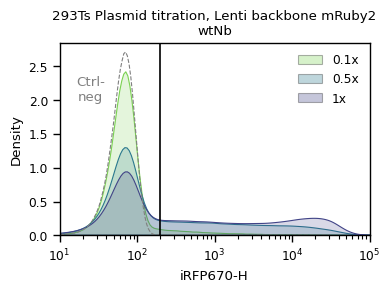

In [8]:
order = ['pKG05003']

label_map = {
    'pKG05003':'Lenti backbone mRuby2\nwtNb'
}

for plasmid in order:
    g = plt.figure(figsize=(4,2.5))
    data_new = data[ (data['reporter'] == plasmid) & (data['iRFP670-H'] > 0)]
    palette = {'0x': 'grey',
            '1x': '#414487FF',
            '0.5x': '#2A788EFF',
            '0.1x': '#7AD151FF' }
    ax = sns.kdeplot(data_new, x='iRFP670-H',hue='Plasmid',log_scale=True,legend=False,fill=True,common_norm=False,palette=palette, alpha = 0.2)
    sns.kdeplot(untransfected, x='iRFP670-H',hue='Plasmid',log_scale=True,legend=False,fill=True,common_norm=False,palette=palette, alpha = 0, linestyle = '--')
    ax.axvline(x = 200, color='black', linestyle='-')
    ax.annotate('Ctrl-\nneg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

    # Add custom legend
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor='#7AD151FF', alpha = 0.3, edgecolor='black', label='0.1x'),
        Patch(facecolor='#2A788EFF', alpha = 0.3,  edgecolor='black', label='0.5x'),
        Patch(facecolor='#414487FF', alpha = 0.3,  edgecolor='black', label='1x')
    ]
    ax.set_xlim([10,10**5])
    ax.legend(handles=legend_elements, frameon=False)
    plt.title(f'293Ts Plasmid titration, {label_map[plasmid]}')
    g = g.get_figure()
    title = 'Figure_S6B_histogram.svg'
    g.savefig(rd.outfile(output_path/title),bbox_inches='tight')

## Gating for FP+ cells

In [9]:
mRuby2_gated = data[data['mRuby2-A'] > mRuby2_gate_quantile].copy()
Double_gated = mRuby2_gated[mRuby2_gated['iRFP670-A'] > iRFP_gate_quantile].copy() 

In [10]:
mRuby2_gated['eGFP_cat'] = np.where(mRuby2_gated['mGL-A'] > eGFP_gate, 'eGFP+', 'eGFP-') 

In [11]:
well_group = ['conds']
count_df = mRuby2_gated.groupby(['conds', 'Date','eGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
percent_small_data_1_mRuby2 = (count_df*100/count_df.groupby(well_group ).transform('sum')).reset_index(name='percent')
count_small_data_1_mRuby2 = count_df.reset_index()
display(percent_small_data_1_mRuby2)

,conds,Date,eGFP_cat,percent
0,Controls.0x,2026.06.29.x,eGFP+,7.267041
1,Controls.0x,2026.06.29.x,eGFP-,92.732959
2,Untransfected.0x,2026.06.29.x,eGFP+,4.713952
3,Untransfected.0x,2026.06.29.x,eGFP-,70.920899
4,Untransfected.0x,2026.07.02.x,eGFP+,0.955925
...,...,...,...,...
147,pKG05003.1x,2026.06.29.x,eGFP-,25.410604
148,pKG05003.1x,2026.07.02.x,eGFP+,2.627945
149,pKG05003.1x,2026.07.02.x,eGFP-,32.645225
150,pKG05003.1x,2026.07.02.xx,eGFP+,2.748260


## Bar plots

**Figure S6A**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\563258258.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\563258258.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lmap[cond] for cond in order])


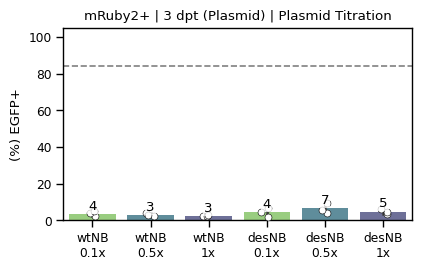

In [12]:
# General plotting params
x = 'conds'
y = 'percent'

# Conditions
order = ['pKG05003.0.1x', 'pKG05003.0.5x', 'pKG05003.1x', 'pKG05002.0.1x','pKG05002.0.5x','pKG05002.1x']
eGFP_cat = 'eGFP+'
color = 'limegreen'

df = percent_small_data_1_mRuby2.loc[percent_small_data_1_mRuby2['eGFP_cat'] == eGFP_cat]
palette = {
    'pKG05003.0.1x': '#7AD151FF', 
    'pKG05003.0.5x': '#2A788EFF', 
    'pKG05003.1x': '#414487FF',
    'pKG05002.0.1x': '#7AD151FF', 
    'pKG05002.0.5x': '#2A788EFF', 
    'pKG05002.1x': '#414487FF'
}


fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    palette=palette,
    alpha=0.8)

sns.stripplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    dodge=True,
    color='white', size=5,
    edgecolor='black', linewidth=0.4,)


lmap = {
    'pKG05003.0.1x': 'wtNB\n0.1x', 
    'pKG05003.0.5x': 'wtNB\n0.5x', 
    'pKG05003.1x': 'wtNB\n1x',
    'pKG05002.0.1x': 'desNB\n0.1x', 
    'pKG05002.0.5x': 'desNB\n0.5x', 
    'pKG05002.1x': 'desNB\n1x'
}
plt.axhline(y=84, color='grey', linestyle= '--')
ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 105))
ax.yaxis.set_label_text('(%) EGFP+')
ax.set_title('mRuby2+ | 3 dpt (Plasmid) | Plasmid Titration')
ax.set_xlabel('')


# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=1)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    
 
plottitle = 'Figure_S6A_EGFP_percent.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

**Figure S6A (with stats)**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\1365848677.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\1365848677.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lmap[cond] for cond in order])


wtNB 0.1x vs 0.5x: p = 0.5059
wtNB 0.1x vs 1x:   p = 0.2305
desNB 0.1x vs 0.5x: p = 0.4082
desNB 0.1x vs 1x:   p = 0.7942


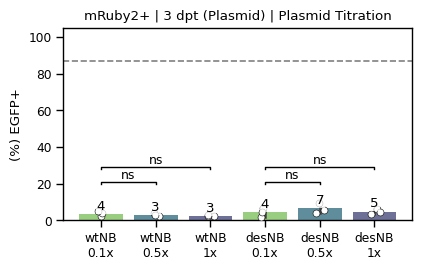

In [13]:
from scipy.stats import ttest_ind
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# General plotting params
x = 'conds'
y = 'percent'

# Conditions
order = [
    'pKG05003.0.1x', 'pKG05003.0.5x', 'pKG05003.1x',
    'pKG05002.0.1x', 'pKG05002.0.5x', 'pKG05002.1x'
]

eGFP_cat = 'eGFP+'
color = 'limegreen'

df = percent_small_data_1_mRuby2.loc[
    percent_small_data_1_mRuby2['eGFP_cat'] == eGFP_cat
]

palette = {
    'pKG05003.0.1x': '#7AD151FF', 
    'pKG05003.0.5x': '#2A788EFF', 
    'pKG05003.1x': '#414487FF',
    'pKG05002.0.1x': '#7AD151FF', 
    'pKG05002.0.5x': '#2A788EFF', 
    'pKG05002.1x': '#414487FF'
}

fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax,
    data=df,
    x=x,
    y=y,
    order=order,
    palette=palette,
    alpha=0.8
)

sns.stripplot(
    ax=ax,
    data=df,
    x=x,
    y=y,
    order=order,
    dodge=True,
    color='white',
    size=5,
    edgecolor='black',
    linewidth=0.4,
)

lmap = {
    'pKG05003.0.1x': 'wtNB\n0.1x', 
    'pKG05003.0.5x': 'wtNB\n0.5x', 
    'pKG05003.1x': 'wtNB\n1x',
    'pKG05002.0.1x': 'desNB\n0.1x', 
    'pKG05002.0.5x': 'desNB\n0.5x', 
    'pKG05002.1x': 'desNB\n1x'
}

plt.axhline(y=87, color='grey', linestyle='--')

ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 105))
ax.yaxis.set_label_text('(%) EGFP+')
ax.set_title('mRuby2+ | 3 dpt (Plasmid) | Plasmid Titration')
ax.set_xlabel('')


# ---------------------------------------------------------
# Add barplot labels
# ---------------------------------------------------------

for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(
            i,
            fmt='%0.0f',
            padding=1
        )
        for label in bar_labels:
            label.set_bbox(
                dict(
                    facecolor='white',
                    alpha=0.75,
                    linewidth=0,
                    pad=1
                )
            )


# ---------------------------------------------------------
# Significance helper
# ---------------------------------------------------------

def add_sig_bar(ax, x1, x2, y, pval, h=1.0, linewidth=1):
    
    # Determine significance label
    if pval < 0.001:
        sig = '***'
    elif pval < 0.01:
        sig = '**'
    elif pval < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    
    # Draw bracket
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=linewidth,
        c='black'
    )
    
    # Add significance text
    ax.text(
        (x1 + x2) / 2,
        y + h + 0.3,
        sig,
        ha='center',
        va='bottom',
        fontsize=9
    )


# ---------------------------------------------------------
# Statistical tests
# ---------------------------------------------------------

# wtNB: 0.1x vs 0.5x
wt_01 = df.loc[df[x] == 'pKG05003.0.1x', y].dropna()
wt_05 = df.loc[df[x] == 'pKG05003.0.5x', y].dropna()

wt_p_05 = ttest_ind(
    wt_01,
    wt_05,
    equal_var=False
).pvalue


# wtNB: 0.1x vs 1x
wt_1 = df.loc[df[x] == 'pKG05003.1x', y].dropna()

wt_p_1 = ttest_ind(
    wt_01,
    wt_1,
    equal_var=False
).pvalue


# desNB: 0.1x vs 0.5x
des_01 = df.loc[df[x] == 'pKG05002.0.1x', y].dropna()
des_05 = df.loc[df[x] == 'pKG05002.0.5x', y].dropna()

des_p_05 = ttest_ind(
    des_01,
    des_05,
    equal_var=False
).pvalue


# desNB: 0.1x vs 1x
des_1 = df.loc[df[x] == 'pKG05002.1x', y].dropna()

des_p_1 = ttest_ind(
    des_01,
    des_1,
    equal_var=False
).pvalue


# ---------------------------------------------------------
# Add significance bars
# ---------------------------------------------------------

# wtNB comparisons
add_sig_bar(
    ax,
    0, 1,
    y=20,
    pval=wt_p_05
)

add_sig_bar(
    ax,
    0, 2,
    y=28,
    pval=wt_p_1
)


# desNB comparisons
add_sig_bar(
    ax,
    3, 4,
    y=20,
    pval=des_p_05
)

add_sig_bar(
    ax,
    3, 5,
    y=28,
    pval=des_p_1
)


# Print exact p-values
print(f"wtNB 0.1x vs 0.5x: p = {wt_p_05:.4g}")
print(f"wtNB 0.1x vs 1x:   p = {wt_p_1:.4g}")
print(f"desNB 0.1x vs 0.5x: p = {des_p_05:.4g}")
print(f"desNB 0.1x vs 1x:   p = {des_p_1:.4g}")


# Save
plottitle = 'Figure_S6A_stats.svg'
plt.savefig(
    rd.outfile(output_path / plottitle),
    bbox_inches='tight'
)

In [15]:
from itertools import combinations
from scipy.stats import ttest_ind

# Filter for eGFP+
df = percent_small_data_1_mRuby2.loc[
    percent_small_data_1_mRuby2['eGFP_cat'] == 'eGFP+'
]

# Reporters and their conditions
reporters = {
    'wtNB': [
        'pKG05003.0.1x',
        'pKG05003.0.5x',
        'pKG05003.1x'
    ],
    'desNB': [
        'pKG05002.0.1x',
        'pKG05002.0.5x',
        'pKG05002.1x'
    ]
}

# Compare every possible pair within each reporter
for reporter, conditions in reporters.items():
    
    print(f'\n{reporter}')
    print('-' * 30)
    
    for cond1, cond2 in combinations(conditions, 2):
        
        values1 = df.loc[df['conds'] == cond1, 'percent'].dropna()
        values2 = df.loc[df['conds'] == cond2, 'percent'].dropna()
        
        pval = ttest_ind(
            values1,
            values2,
            equal_var=False
        ).pvalue
        
        print(f'{cond1} vs {cond2}: p = {pval:.4g}')


wtNB
------------------------------
pKG05003.0.1x vs pKG05003.0.5x: p = 0.5059
pKG05003.0.1x vs pKG05003.1x: p = 0.2305
pKG05003.0.5x vs pKG05003.1x: p = 0.2801

desNB
------------------------------
pKG05002.0.1x vs pKG05002.0.5x: p = 0.4082
pKG05002.0.1x vs pKG05002.1x: p = 0.7942
pKG05002.0.5x vs pKG05002.1x: p = 0.4525


## Small Contours

**Figure S6C**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\170447798.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\170447798.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\170447798.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


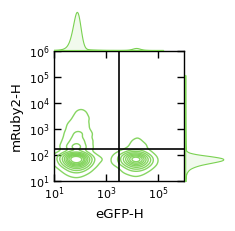

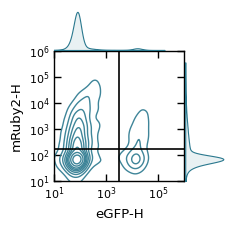

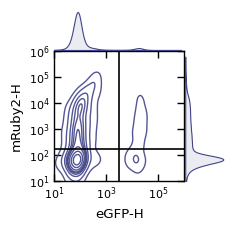

In [16]:
# General plotting params
y = "mRuby2-H"
x = "mGL-H"
hue = "Plasmid"
hue_order = Plasmid_conds_2

# Conditions
palette = {'0x': 'grey',
    '1x': '#414487FF',
    '0.5x': '#2A788EFF',
    '0.1x': '#7AD151FF' }

for amount in Plasmid_conds_2:

        # Conditions
    data_now = data[
        (data['reporter'] == 'pKG05003') &
        (data['Plasmid'] == amount) & (data['mRuby2-H'] > 0) & (data['mGL-H'] > 0)
    ]

    small_data = pd.concat([data_now])

    # ----------------------------------------------------
    # Define bottom-left quadrant:
    # below BOTH gates
    # ----------------------------------------------------
    bottom_left = small_data[
        (small_data[x] < eGFP_gate) &
        (small_data[y] < mRuby2_gate_quantile)
    ]

    # Everything else
    not_bottom_left = small_data[
        ~(
            (small_data[x] < eGFP_gate) &
            (small_data[y] < mRuby2_gate_quantile)
        )
    ]

    # ----------------------------------------------------
    # Sample:
    # 1000 from bottom-left
    # 10000 from everything else
    # ----------------------------------------------------
    sampled_bottom_left = bottom_left.sample(
        min(len(bottom_left), 5000),
        random_state=1
    )

    sampled_not_bottom_left = not_bottom_left.sample(
        min(len(not_bottom_left), 5000),
        random_state=1
    )

    # Combine sampled data
    small_data_sampled = pd.concat([
        sampled_bottom_left,
        sampled_not_bottom_left
    ])

    # definitions for the axes
    left, width = 0.1, 0.65
    bottom, height = 0.1, 0.65
    spacing = 0.005

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom + height + spacing, width, 0.2]
    rect_histy = [left + width + spacing, bottom, 0.2, height]

    # Set up figure
    fig = plt.figure(figsize=(2, 2))

    ax_scatter = plt.axes(rect_scatter)
    ax_scatter.tick_params(direction="in", top=True, right=True, labelsize=8)

    ax_histx = plt.axes(rect_histx)
    ax_histx.set_axis_off()

    ax_histy = plt.axes(rect_histy)
    ax_histy.set_axis_off()

    # Set limits
    mRuby2_lim = (10, 1e6)
    mCherry_lim = (10, 1e6)

    ylim = mRuby2_lim
    xlim = mCherry_lim

    ax_scatter.set_xlim(xlim)
    ax_scatter.set_ylim(ylim)

    ax_histx.set_xlim(xlim)
    ax_histy.set_ylim(ylim)

    # ----------------------------------------------------
    # Contour plot
    # ----------------------------------------------------
    sns.kdeplot(
        ax=ax_scatter,
        data=small_data_sampled,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        palette=palette,
        fill=False,
        levels=10,
        thresh=0.05,
        alpha=0.9,
        linewidths=1,
        legend=False,
        log_scale=True
    )

    ax_scatter.set_xscale('log')
    ax_scatter.set_yscale('log')



    # Remove minor ticks on the y-axis
    ax_scatter.yaxis.set_minor_locator(NullLocator())
    ax_scatter.tick_params(axis='y', which='minor', left=False, right=False)

    # Marginal KDEs
    sns.kdeplot(
        ax=ax_histx,
        data=small_data,
        x=x,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    sns.kdeplot(
        ax=ax_histy,
        data=small_data,
        y=y,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    # Thresholds
    ax_scatter.axhline(mRuby2_gate_quantile, 0, 1, color='black')
    ax_scatter.axvline(eGFP_gate, 0, 1, color='black')
    ax_scatter.set_xlabel('eGFP-H')

    fig.tight_layout()

    plottitle = str(amount) + 'Figure_S6C.svg'

    plt.savefig(
        rd.outfile(output_path / plottitle),
        bbox_inches='tight'
    )

**Figure S6D**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\2760551902.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\2760551902.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_41540\2760551902.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


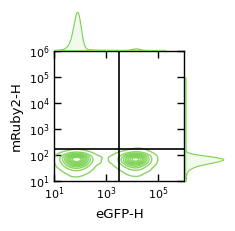

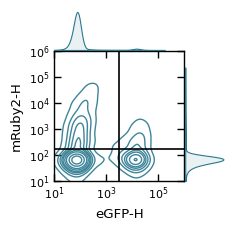

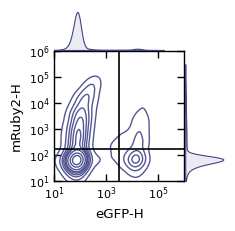

In [17]:
# General plotting params
y = "mRuby2-H"
x = "mGL-H"
hue = "Plasmid"
hue_order = Plasmid_conds_2

# Conditions
palette = {'0x': 'grey',
    '1x': '#414487FF',
    '0.5x': '#2A788EFF',
    '0.1x': '#7AD151FF' }

for amount in Plasmid_conds_2:

        # Conditions
    data_now = data[
        (data['reporter'] == 'pKG05002') &
        (data['Plasmid'] == amount)  & (data['mGL-H'] > 0 ) & (data['mRuby2-H'] > 0)
    ]

    small_data = pd.concat([data_now])

    # ----------------------------------------------------
    # Define bottom-left quadrant:
    # below BOTH gates
    # ----------------------------------------------------
    bottom_left = small_data[
        (small_data[x] < eGFP_gate) &
        (small_data[y] < mRuby2_gate_quantile)
    ]

    # Everything else
    not_bottom_left = small_data[
        ~(
            (small_data[x] < eGFP_gate) &
            (small_data[y] < mRuby2_gate_quantile)
        )
    ]

    # ----------------------------------------------------
    # Sample:
    # 1000 from bottom-left
    # 10000 from everything else
    # ----------------------------------------------------
    sampled_bottom_left = bottom_left.sample(
        min(len(bottom_left), 5000),
        random_state=1
    )

    sampled_not_bottom_left = not_bottom_left.sample(
        min(len(not_bottom_left), 5000),
        random_state=1
    )

    # Combine sampled data
    small_data_sampled = pd.concat([
        sampled_bottom_left,
        sampled_not_bottom_left
    ])

    # definitions for the axes
    left, width = 0.1, 0.65
    bottom, height = 0.1, 0.65
    spacing = 0.005

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom + height + spacing, width, 0.2]
    rect_histy = [left + width + spacing, bottom, 0.2, height]

    # Set up figure
    fig = plt.figure(figsize=(2, 2))

    ax_scatter = plt.axes(rect_scatter)
    ax_scatter.tick_params(direction="in", top=True, right=True, labelsize=8)

    ax_histx = plt.axes(rect_histx)
    ax_histx.set_axis_off()

    ax_histy = plt.axes(rect_histy)
    ax_histy.set_axis_off()

    # Set limits
    mRuby2_lim = (10, 1e6)
    mCherry_lim = (10, 1e6)

    ylim = mRuby2_lim
    xlim = mCherry_lim

    ax_scatter.set_xlim(xlim)
    ax_scatter.set_ylim(ylim)

    ax_histx.set_xlim(xlim)
    ax_histy.set_ylim(ylim)

    # ----------------------------------------------------
    # Contour plot
    # ----------------------------------------------------
    sns.kdeplot(
        ax=ax_scatter,
        data=small_data_sampled,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        palette=palette,
        fill=False,
        levels=10,
        thresh=0.05,
        alpha=0.9,
        linewidths=1,
        legend=False,
        log_scale=True
    )

    ax_scatter.set_xscale('log')
    ax_scatter.set_yscale('log')



    # Remove minor ticks on the y-axis
    ax_scatter.yaxis.set_minor_locator(NullLocator())
    ax_scatter.tick_params(axis='y', which='minor', left=False, right=False)

    # Marginal KDEs
    sns.kdeplot(
        ax=ax_histx,
        data=small_data,
        x=x,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    sns.kdeplot(
        ax=ax_histy,
        data=small_data,
        y=y,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    # Thresholds
    ax_scatter.axhline(mRuby2_gate_quantile, 0, 1, color='black')
    ax_scatter.axvline(eGFP_gate, 0, 1, color='black')
    ax_scatter.set_xlabel('eGFP-H')

    fig.tight_layout()

    plottitle = str(amount) + 'Figure_S6D.svg'

    plt.savefig(
        rd.outfile(output_path / plottitle),
        bbox_inches='tight'
    )